## This code was generated using LLM (claud), By the instructions, requirements and design given by students to support visualsing, proving and comparing our chosed algorithm AOA vs AGWO in the TSP case.

Running AOA (10 runs, 30 agents, 500 iterations)...
  Run 1: distance=8720.8, time=6.24s
  Run 2: distance=8178.9, time=4.82s
  Run 3: distance=8437.4, time=5.44s
  Run 4: distance=8379.3, time=9.28s
  Run 5: distance=8482.8, time=8.07s
  Run 6: distance=7742.6, time=9.64s
  Run 7: distance=8198.5, time=8.80s
  Run 8: distance=8448.8, time=8.76s
  Run 9: distance=8406.3, time=8.92s
  Run 10: distance=8520.6, time=8.80s

Running AGWO (10 runs, 30 wolves, 500 iterations)...
  Run 1: distance=8163.5, time=11.25s
  Run 2: distance=8001.9, time=12.49s
  Run 3: distance=8158.3, time=11.74s
  Run 4: distance=8261.7, time=11.50s
  Run 5: distance=8217.0, time=12.71s
  Run 6: distance=8211.8, time=11.44s
  Run 7: distance=8336.0, time=11.96s
  Run 8: distance=8426.6, time=10.98s
  Run 9: distance=8152.9, time=12.59s
  Run 10: distance=8781.0, time=12.52s

Generating all plots...
Saved: fig1_convergence.png
Saved: fig2_route_aoa.png
Saved: fig3_route_agwo.png
Saved: fig4_comparison_bar.png
Saved

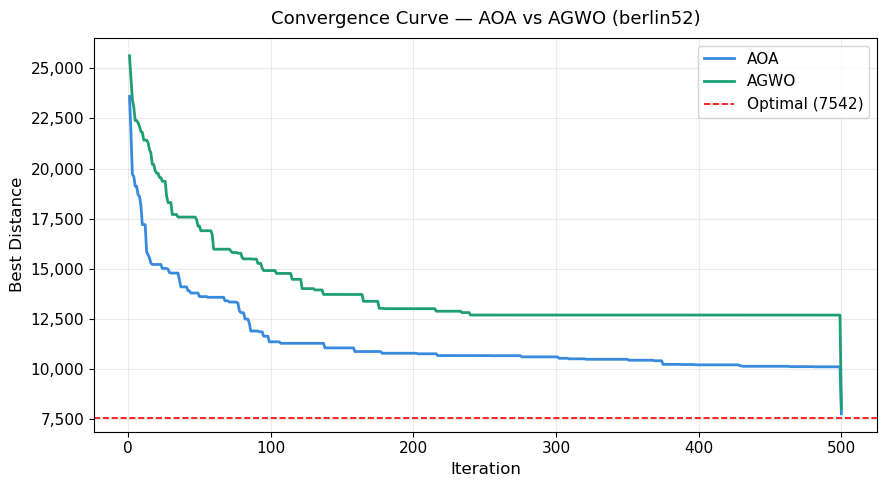

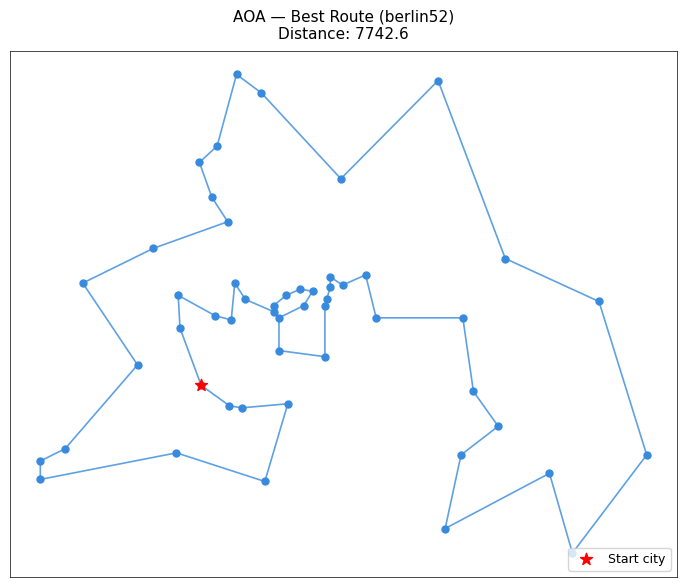

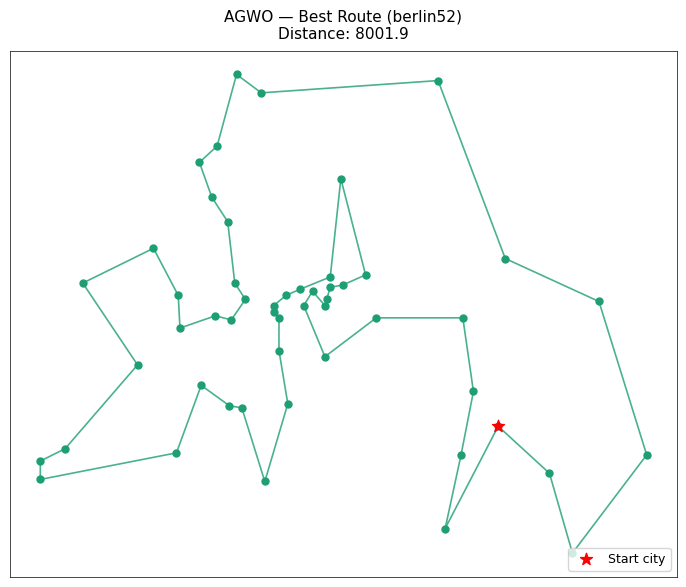

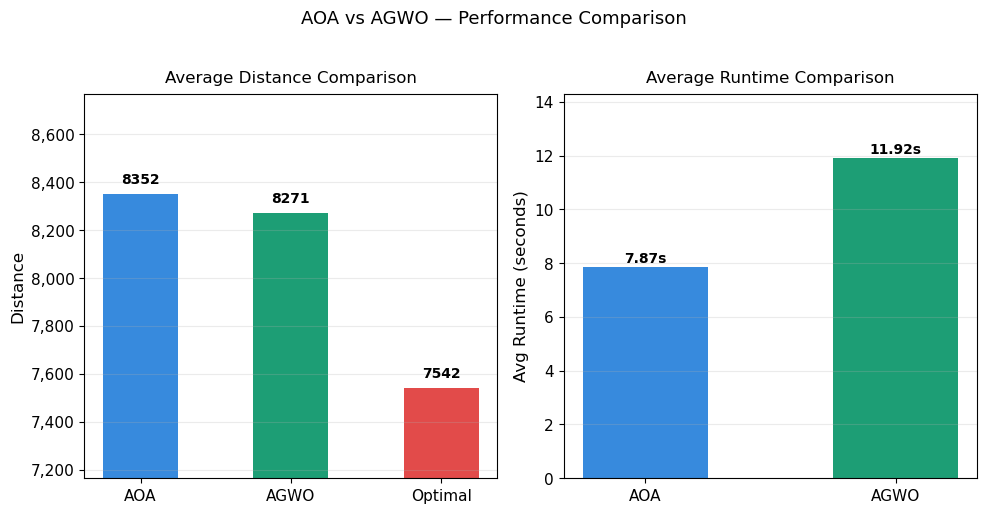

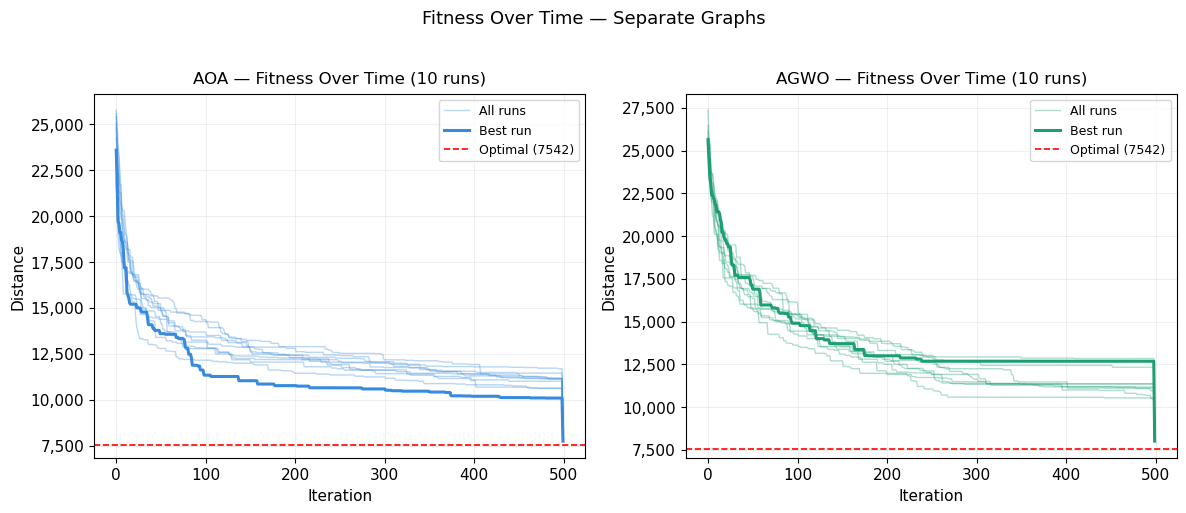

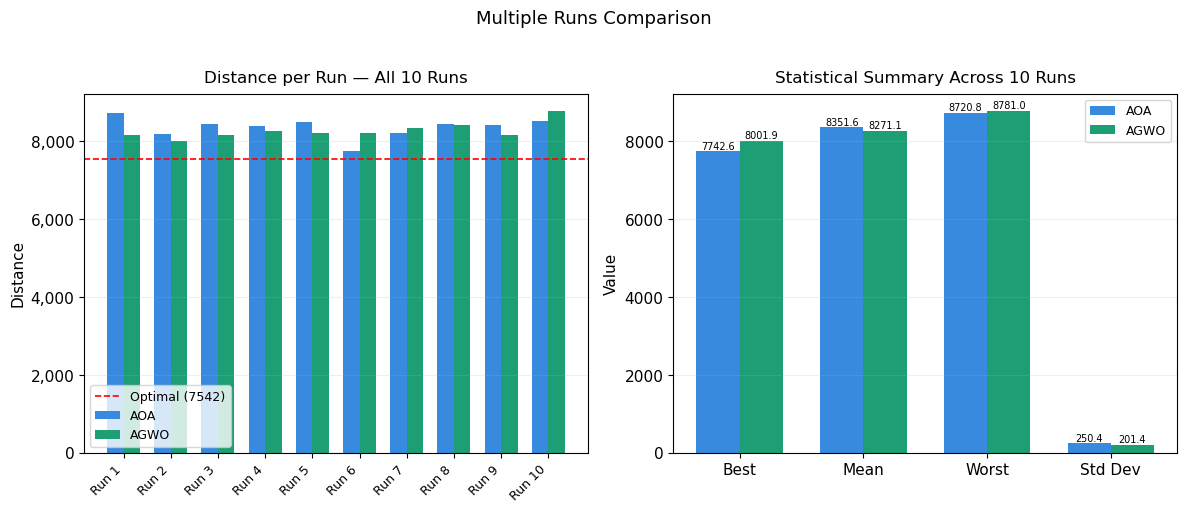

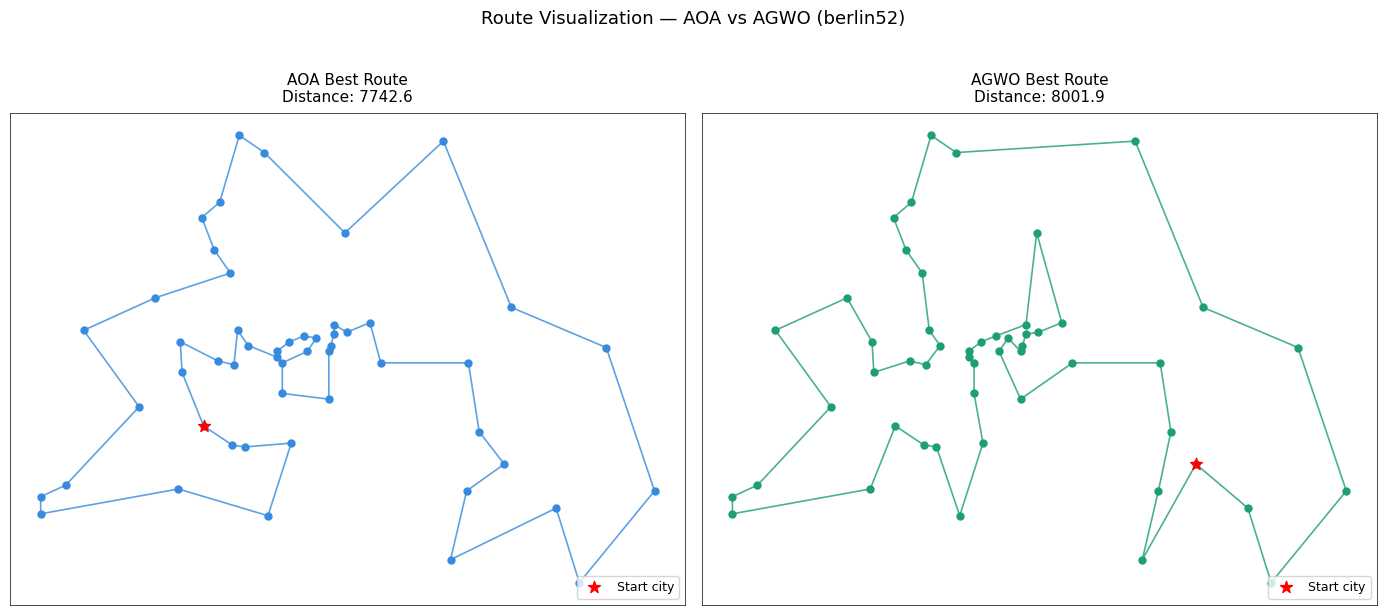

In [4]:
"""
TSP - AOA vs Adaptive Grey Wolf Optimization (AGWO)
Dataset: berlin52 TSPLIB benchmark
Requirements: pip install numpy matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import time
import random

# ─────────────────────────────────────────────
# BERLIN52 TSPLIB COORDINATES
# Source: Reinelt, G. (1991). TSPLIB.
# http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/
# ─────────────────────────────────────────────
BERLIN52 = [
    (565,575),(25,185),(345,750),(945,685),(845,655),(880,660),(25,230),
    (525,1000),(580,1175),(650,1130),(1605,620),(1220,580),(1465,200),
    (1530,5),(845,680),(725,370),(145,665),(415,635),(510,875),(560,365),
    (300,465),(520,585),(480,415),(835,625),(975,580),(1215,245),(1320,315),
    (1250,400),(660,180),(410,250),(420,555),(575,665),(1150,1160),(700,580),
    (685,595),(685,610),(770,610),(795,645),(720,635),(760,650),(475,960),
    (95,260),(875,920),(700,500),(555,815),(830,485),(1170,65),(830,610),
    (605,625),(595,360),(1340,725),(1740,245)
]
cities = np.array(BERLIN52)
N = len(cities)
OPTIMAL = 7542  # known optimal for berlin52


# ─────────────────────────────────────────────
# DISTANCE HELPERS
# ─────────────────────────────────────────────
def dist(a, b):
    return np.sqrt((cities[a][0]-cities[b][0])**2 + (cities[a][1]-cities[b][1])**2)

def route_length(route):
    return sum(dist(route[i], route[(i+1) % N]) for i in range(N))

def two_opt(route, max_iter=1000):
    best = route[:]
    improved = True
    it = 0
    while improved and it < max_iter:
        improved = False
        it += 1
        for i in range(1, N - 1):
            for j in range(i + 1, N):
                new = best[:i] + best[i:j+1][::-1] + best[j+1:]
                if route_length(new) < route_length(best):
                    best = new
                    improved = True
    return best


# ─────────────────────────────────────────────
# ARITHMETIC OPTIMIZATION ALGORITHM (AOA)
# ─────────────────────────────────────────────
def aoa_tsp(n_agents=30, max_iter=500, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    population = [list(np.random.permutation(N)) for _ in range(n_agents)]
    fitness = [route_length(r) for r in population]
    best_idx = np.argmin(fitness)
    best_route = population[best_idx][:]
    best_dist = fitness[best_idx]

    history = []
    alpha = 5

    for t in range(max_iter):
        MOA = 0.1 + t * ((1 - 0.1) / max_iter)
        MOP = 1 - (t**(1/alpha)) / (max_iter**(1/alpha))

        for i in range(n_agents):
            r = random.random()
            if r > MOA:
                new_route = best_route[:]
                for _ in range(2):
                    a, b = random.sample(range(N), 2)
                    new_route[a], new_route[b] = new_route[b], new_route[a]
            else:
                new_route = population[i][:]
                a = random.randint(0, N-1)
                b = random.randint(0, N-1)
                city = new_route.pop(a)
                new_route.insert(b, city)

            new_dist = route_length(new_route)
            if new_dist < fitness[i]:
                population[i] = new_route
                fitness[i] = new_dist
                if new_dist < best_dist:
                    best_dist = new_dist
                    best_route = new_route[:]

        history.append(best_dist)

    best_route = two_opt(best_route, max_iter=1000)
    best_dist = route_length(best_route)
    history[-1] = best_dist

    return best_route, best_dist, history


# ─────────────────────────────────────────────
# ADAPTIVE GREY WOLF OPTIMIZATION (AGWO)
# Adaptations over standard GWO:
#   1. Non-linear adaptive decay of 'a' using a sigmoid-based curve
#      instead of linear decrease, giving stronger early exploration
#   2. Fitness-proportional wolf weights: alpha/beta/delta influence
#      is weighted by their relative fitness gap, not equal 1/3 blend
#   3. Stagnation restart: if best fitness does not improve for
#      STAGNATION_LIMIT iterations, wolves are partially re-initialized
#      to escape local optima
# ─────────────────────────────────────────────
def agwo_tsp(n_wolves=30, max_iter=500, seed=42):
    np.random.seed(seed)
    random.seed(seed)

    STAGNATION_LIMIT = 50

    population = [list(np.random.permutation(N)) for _ in range(n_wolves)]
    fitness = [route_length(r) for r in population]

    sorted_idx = np.argsort(fitness)
    alpha_wolf = population[sorted_idx[0]][:]
    beta_wolf  = population[sorted_idx[1]][:]
    delta_wolf = population[sorted_idx[2]][:]
    alpha_fit  = fitness[sorted_idx[0]]
    beta_fit   = fitness[sorted_idx[1]]
    delta_fit  = fitness[sorted_idx[2]]

    history = []
    no_improve_count = 0
    prev_best = alpha_fit

    for t in range(max_iter):

        # Adaptation 1: Non-linear 'a' decay (sigmoid-based)
        progress = t / max_iter
        a = 2 * (1 - 1 / (1 + np.exp(-10 * (progress - 0.5))))

        # Adaptation 2: Fitness-proportional wolf weights
        fits = np.array([alpha_fit, beta_fit, delta_fit], dtype=float)
        inv = 1.0 / (fits + 1e-9)
        weights = inv / inv.sum()
        w_alpha, w_beta, w_delta = weights

        for i in range(n_wolves):
            r = random.random()
            if r < w_alpha:
                guide = alpha_wolf
            elif r < w_alpha + w_beta:
                guide = beta_wolf
            else:
                guide = delta_wolf

            new_route = [None] * N
            start, end = sorted(random.sample(range(N), 2))
            new_route[start:end] = guide[start:end]
            remaining = [c for c in population[i] if c not in new_route]
            ptr = 0
            for j in range(N):
                if new_route[j] is None:
                    new_route[j] = remaining[ptr]
                    ptr += 1

            if a > 1.0:
                p = random.randint(0, N-1)
                q = random.randint(0, N-1)
                new_route[p], new_route[q] = new_route[q], new_route[p]

            new_dist = route_length(new_route)
            if new_dist < fitness[i]:
                population[i] = new_route
                fitness[i] = new_dist

        sorted_idx = np.argsort(fitness)
        alpha_wolf = population[sorted_idx[0]][:]
        beta_wolf  = population[sorted_idx[1]][:]
        delta_wolf = population[sorted_idx[2]][:]
        alpha_fit  = fitness[sorted_idx[0]]
        beta_fit   = fitness[sorted_idx[1]]
        delta_fit  = fitness[sorted_idx[2]]

        # Adaptation 3: Stagnation restart
        if alpha_fit < prev_best:
            prev_best = alpha_fit
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= STAGNATION_LIMIT:
            half = n_wolves // 2
            for i in sorted_idx[half:]:
                population[i] = list(np.random.permutation(N))
                fitness[i] = route_length(population[i])
            no_improve_count = 0

        history.append(alpha_fit)

    alpha_wolf = two_opt(alpha_wolf, max_iter=1000)
    alpha_fit  = route_length(alpha_wolf)
    history[-1] = alpha_fit

    return alpha_wolf, alpha_fit, history


# ─────────────────────────────────────────────
# MULTIPLE RUNS
# ─────────────────────────────────────────────
def run_multiple(algo_fn, n_runs=10, n_agents=30, max_iter=500):
    results = []
    times = []
    for i in range(n_runs):
        t0 = time.time()
        try:
            route, dist_val, hist = algo_fn(n_agents=n_agents, max_iter=max_iter, seed=i*7+13)
        except TypeError:
            route, dist_val, hist = algo_fn(n_wolves=n_agents, max_iter=max_iter, seed=i*7+13)
        elapsed = time.time() - t0
        results.append((route, dist_val, hist))
        times.append(elapsed)
        print(f"  Run {i+1}: distance={dist_val:.1f}, time={elapsed:.2f}s")
    return results, times


# ─────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────
BLUE  = '#378ADD'
GREEN = '#1D9E75'
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

def plot_route(ax, route, color, title, dist_val):
    coords = np.array([cities[r] for r in route] + [cities[route[0]]])
    ax.plot(coords[:,0], coords[:,1], '-', color=color, linewidth=1.2, alpha=0.8)
    ax.scatter(cities[:,0], cities[:,1], s=25, color=color, zorder=5)
    ax.scatter(cities[route[0],0], cities[route[0],1], s=80,
               color='red', zorder=6, marker='*', label='Start city')
    ax.set_title(f"{title}\nDistance: {dist_val:.1f}", fontsize=11, pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=9, loc='lower right')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

def make_all_plots(aoa_results, aoa_times, agwo_results, agwo_times):

    aoa_best_idx  = np.argmin([r[1] for r in aoa_results])
    agwo_best_idx = np.argmin([r[1] for r in agwo_results])
    aoa_best_route,  aoa_best_dist,  aoa_best_hist  = aoa_results[aoa_best_idx]
    agwo_best_route, agwo_best_dist, agwo_best_hist = agwo_results[agwo_best_idx]

    aoa_dists  = [r[1] for r in aoa_results]
    agwo_dists = [r[1] for r in agwo_results]

    # computed averages used across figures
    avg_aoa_dist  = np.mean(aoa_dists)
    avg_agwo_dist = np.mean(agwo_dists)
    avg_aoa_time  = np.mean(aoa_times)
    avg_agwo_time = np.mean(agwo_times)

    # ── FIGURE 1: Convergence curve ───────────────────────────────────────────
    fig1, ax = plt.subplots(figsize=(9, 5))
    iters = range(1, len(aoa_best_hist)+1)
    ax.plot(iters, aoa_best_hist,  color=BLUE,  linewidth=2, label='AOA')
    ax.plot(iters, agwo_best_hist, color=GREEN, linewidth=2, label='AGWO')
    ax.axhline(y=OPTIMAL, color='red', linewidth=1.2, linestyle='--', label=f'Optimal ({OPTIMAL})')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Best Distance', fontsize=12)
    ax.set_title('Convergence Curve — AOA vs AGWO (berlin52)', fontsize=13, pad=10)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    fig1.savefig('fig1_convergence.png', dpi=150, bbox_inches='tight')
    print("Saved: fig1_convergence.png")

    # ── FIGURE 2: AOA Route ───────────────────────────────────────────────────
    fig2, ax = plt.subplots(figsize=(7, 6))
    plot_route(ax, aoa_best_route, BLUE, 'AOA — Best Route (berlin52)', aoa_best_dist)
    plt.tight_layout()
    fig2.savefig('fig2_route_aoa.png', dpi=150, bbox_inches='tight')
    print("Saved: fig2_route_aoa.png")

    # ── FIGURE 3: AGWO Route ──────────────────────────────────────────────────
    fig3, ax = plt.subplots(figsize=(7, 6))
    plot_route(ax, agwo_best_route, GREEN, 'AGWO — Best Route (berlin52)', agwo_best_dist)
    plt.tight_layout()
    fig3.savefig('fig3_route_agwo.png', dpi=150, bbox_inches='tight')
    print("Saved: fig3_route_agwo.png")

    # ── FIGURE 4: Average distance AND average runtime comparison ─────────────
    fig4, axes = plt.subplots(1, 2, figsize=(10, 5))

    # LEFT: Average distance comparison (includes optimal reference)
    ax1 = axes[0]
    avg_vals = [avg_aoa_dist, avg_agwo_dist, OPTIMAL]
    avg_labels = ['AOA', 'AGWO', 'Optimal']
    bars1 = ax1.bar(avg_labels, avg_vals,
                    color=[BLUE, GREEN, '#E24B4A'], width=0.5)
    ax1.set_ylabel('Distance', fontsize=12)
    ax1.set_title('Average Distance Comparison', fontsize=12, pad=8)
    ax1.set_ylim(min(avg_vals) * 0.95, max(avg_vals) * 1.05)
    for bar, val in zip(bars1, avg_vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.grid(axis='y', alpha=0.25)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # RIGHT: Average runtime comparison
    ax2 = axes[1]
    bars2 = ax2.bar(['AOA', 'AGWO'], [avg_aoa_time, avg_agwo_time],
                    color=[BLUE, GREEN], width=0.5)
    ax2.set_ylabel('Avg Runtime (seconds)', fontsize=12)
    ax2.set_title('Average Runtime Comparison', fontsize=12, pad=8)
    ax2.set_ylim(0, max(avg_aoa_time, avg_agwo_time) * 1.2)
    for bar, val in zip(bars2, [avg_aoa_time, avg_agwo_time]):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax2.grid(axis='y', alpha=0.25)

    plt.suptitle('AOA vs AGWO — Performance Comparison', fontsize=13, y=1.02)
    plt.tight_layout()
    fig4.savefig('fig4_comparison_bar.png', dpi=150, bbox_inches='tight')
    print("Saved: fig4_comparison_bar.png")

    # ── FIGURE 5: Separate fitness over time ──────────────────────────────────
    fig5, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    for i, (route, dist_val, hist) in enumerate(aoa_results):
        a = 0.35 if i != aoa_best_idx else 1.0
        lw = 1 if i != aoa_best_idx else 2.2
        label = 'Best run' if i == aoa_best_idx else ('All runs' if i == 0 else None)
        ax1.plot(hist, color=BLUE, alpha=a, linewidth=lw, label=label)
    ax1.axhline(y=OPTIMAL, color='red', linewidth=1.2, linestyle='--', label=f'Optimal ({OPTIMAL})')
    ax1.set_title('AOA — Fitness Over Time (10 runs)', fontsize=12, pad=8)
    ax1.set_xlabel('Iteration'); ax1.set_ylabel('Distance')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.2)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    for i, (route, dist_val, hist) in enumerate(agwo_results):
        a = 0.35 if i != agwo_best_idx else 1.0
        lw = 1 if i != agwo_best_idx else 2.2
        label = 'Best run' if i == agwo_best_idx else ('All runs' if i == 0 else None)
        ax2.plot(hist, color=GREEN, alpha=a, linewidth=lw, label=label)
    ax2.axhline(y=OPTIMAL, color='red', linewidth=1.2, linestyle='--', label=f'Optimal ({OPTIMAL})')
    ax2.set_title('AGWO — Fitness Over Time (10 runs)', fontsize=12, pad=8)
    ax2.set_xlabel('Iteration'); ax2.set_ylabel('Distance')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    plt.suptitle('Fitness Over Time — Separate Graphs', fontsize=13, y=1.02)
    plt.tight_layout()
    fig5.savefig('fig5_fitness_over_time.png', dpi=150, bbox_inches='tight')
    print("Saved: fig5_fitness_over_time.png")

    # ── FIGURE 6: Multiple runs comparison ───────────────────────────────────
    fig6, axes = plt.subplots(1, 2, figsize=(12, 5))

    run_labels = [f'Run {i+1}' for i in range(len(aoa_results))]
    x = np.arange(len(run_labels))
    w = 0.35

    ax1 = axes[0]
    ax1.bar(x - w/2, aoa_dists,  w, label='AOA',  color=BLUE)
    ax1.bar(x + w/2, agwo_dists, w, label='AGWO', color=GREEN)
    ax1.axhline(y=OPTIMAL, color='red', linewidth=1.2, linestyle='--', label=f'Optimal ({OPTIMAL})')
    ax1.set_xticks(x); ax1.set_xticklabels(run_labels, rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Distance'); ax1.set_title('Distance per Run — All 10 Runs', fontsize=12, pad=8)
    ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.2)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    ax2 = axes[1]
    stats_labels = ['Best', 'Mean', 'Worst', 'Std Dev']
    aoa_stats  = [min(aoa_dists),  np.mean(aoa_dists),  max(aoa_dists),  np.std(aoa_dists)]
    agwo_stats = [min(agwo_dists), np.mean(agwo_dists), max(agwo_dists), np.std(agwo_dists)]
    x2 = np.arange(len(stats_labels))
    ax2.bar(x2 - w/2, aoa_stats,  w, label='AOA',  color=BLUE)
    ax2.bar(x2 + w/2, agwo_stats, w, label='AGWO', color=GREEN)
    ax2.set_xticks(x2); ax2.set_xticklabels(stats_labels)
    ax2.set_ylabel('Value'); ax2.set_title('Statistical Summary Across 10 Runs', fontsize=12, pad=8)
    ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.2)
    for bar in ax2.patches:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=7)

    plt.suptitle('Multiple Runs Comparison', fontsize=13, y=1.02)
    plt.tight_layout()
    fig6.savefig('fig6_multiple_runs.png', dpi=150, bbox_inches='tight')
    print("Saved: fig6_multiple_runs.png")

    # ── FIGURE 7: Side-by-side routes ────────────────────────────────────────
    fig7, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    plot_route(ax1, aoa_best_route,  BLUE,  'AOA Best Route',  aoa_best_dist)
    plot_route(ax2, agwo_best_route, GREEN, 'AGWO Best Route', agwo_best_dist)
    plt.suptitle('Route Visualization — AOA vs AGWO (berlin52)', fontsize=13, y=1.02)
    plt.tight_layout()
    fig7.savefig('fig7_routes_side_by_side.png', dpi=150, bbox_inches='tight')
    print("Saved: fig7_routes_side_by_side.png")

    # Print summary table
    print("\n" + "="*55)
    print(f"{'Metric':<25} {'AOA':>12} {'AGWO':>12}")
    print("="*55)
    print(f"{'Best distance':<25} {min(aoa_dists):>12.1f} {min(agwo_dists):>12.1f}")
    print(f"{'Mean distance':<25} {avg_aoa_dist:>12.1f} {avg_agwo_dist:>12.1f}")
    print(f"{'Worst distance':<25} {max(aoa_dists):>12.1f} {max(agwo_dists):>12.1f}")
    print(f"{'Std deviation':<25} {np.std(aoa_dists):>12.2f} {np.std(agwo_dists):>12.2f}")
    print(f"{'Avg runtime (s)':<25} {avg_aoa_time:>12.2f} {avg_agwo_time:>12.2f}")
    print(f"{'Known optimal':<25} {OPTIMAL:>12} {OPTIMAL:>12}")
    print(f"{'Optimality gap':<25} {(min(aoa_dists)-OPTIMAL)/OPTIMAL*100:>11.2f}% {(min(agwo_dists)-OPTIMAL)/OPTIMAL*100:>11.2f}%")
    print("="*55)

    plt.show()


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────
if __name__ == '__main__':
    N_RUNS   = 10
    N_AGENTS = 30
    MAX_ITER = 500

    print(f"Running AOA ({N_RUNS} runs, {N_AGENTS} agents, {MAX_ITER} iterations)...")
    aoa_results, aoa_times = run_multiple(aoa_tsp, N_RUNS, N_AGENTS, MAX_ITER)

    print(f"\nRunning AGWO ({N_RUNS} runs, {N_AGENTS} wolves, {MAX_ITER} iterations)...")
    agwo_results, agwo_times = run_multiple(agwo_tsp, N_RUNS, N_AGENTS, MAX_ITER)

    print("\nGenerating all plots...")
    make_all_plots(aoa_results, aoa_times, agwo_results, agwo_times)

In [6]:
import pandas as pd

# Build table from REAL results
aoa_dists  = [r[1] for r in aoa_results]
agwo_dists = [r[1] for r in agwo_results]

data = {
    "Algorithm":      ["AOA", "AGWO", "Optimal"],
    "Cities":         [52, 52, 52],
    "Best Dist.":     [round(min(aoa_dists), 1),        round(min(agwo_dists), 1),        7542],
    "Avg. Dist.":     [round(np.mean(aoa_dists), 1),    round(np.mean(agwo_dists), 1),    "—"],
    "Worst Dist.":    [round(max(aoa_dists), 1),         round(max(agwo_dists), 1),         "—"],
    "Std Dev (σ)":    [round(np.std(aoa_dists), 1),     round(np.std(agwo_dists), 1),     "—"],
    "Avg Runtime (s)":[round(np.mean(aoa_times), 2),    round(np.mean(agwo_times), 2),    "—"],
    "Gap %":          [
        f"{(min(aoa_dists)-7542)/7542*100:.2f}%",
        f"{(min(agwo_dists)-7542)/7542*100:.2f}%",
        "0%"
    ]
}

df = pd.DataFrame(data)
print("\nTable 1: Performance Comparison of AOA and AGWO")
print("=" * 75)
print(df.to_string(index=False))



Table 1: Performance Comparison of AOA and AGWO
Algorithm  Cities  Best Dist. Avg. Dist. Worst Dist. Std Dev (σ) Avg Runtime (s) Gap %
      AOA      52      7742.6     8351.6      8720.8       250.4            7.87 2.66%
     AGWO      52      8001.9     8271.1      8781.0       201.4           11.92 6.10%
  Optimal      52      7542.0          —           —           —               —    0%
